# **Topic Modelling of McDonald's Store Reviews**

**Objective:** Utilize Latent Dirichlet Allocation (LDA) to extract actionable business insights from 33,000+ customer reviews.

# **Project Phase 1: Data Exploration and Understanding**
## **1.0 Data Loading and Initial Inspection**
In this section, we load the dataset and perform a high-level check of the number of reviews and features available.

 **Dataset Overview**

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


In [ ]:
from google.colab import files
import io

print("Please upload 'McDonald_s_Reviews.csv' from your local machine.")
uploaded = files.upload()

if 'McDonald_s_Reviews.csv' in uploaded:
    McD = pd.read_csv(io.BytesIO(uploaded['McDonald_s_Reviews.csv']), encoding='latin1')
    print("Dataset loaded successfully!")
    display(McD.head())
else:
    print("File not found in upload. Please ensure the filename matches exactly.")

Please upload 'McDonald_s_Reviews.csv' from your local machine.


Saving McDonald_s_Reviews.csv to McDonald_s_Reviews.csv
Dataset loaded successfully!


,reviewer_id,store_name,category,store_address,latitude,longitude,rating_count,review_time,review,rating
0,1,McDonald's,Fast food restaurant,"13749 US-183 Hwy, Austin, TX 78750, United States",30.460718,-97.792874,"1,240",3 months ago,Why does it look like someone spit on my food?...,1 star
1,2,McDonald's,Fast food restaurant,"13749 US-183 Hwy, Austin, TX 78750, United States",30.460718,-97.792874,"1,240",5 days ago,It'd McDonalds. It is what it is as far as the...,4 stars
2,3,McDonald's,Fast food restaurant,"13749 US-183 Hwy, Austin, TX 78750, United States",30.460718,-97.792874,"1,240",5 days ago,Made a mobile order got to the speaker and che...,1 star
3,4,McDonald's,Fast food restaurant,"13749 US-183 Hwy, Austin, TX 78750, United States",30.460718,-97.792874,"1,240",a month ago,My mc. Crispy chicken sandwich was ï¿½ï¿½ï¿½ï¿...,5 stars
4,5,McDonald's,Fast food restaurant,"13749 US-183 Hwy, Austin, TX 78750, United States",30.460718,-97.792874,"1,240",2 months ago,"I repeat my order 3 times in the drive thru, a...",1 star


# **How many reviews are in the dataset**?

In [ ]:
import pandas as pd
import os

# Fix: Automatically find the uploaded file even if it was renamed (e.g. version (3))
possible_files = [f for f in os.listdir('/content') if 'McDonald_s_Reviews' in f and f.endswith('.csv')]

if possible_files:
    # Load the latest version found
    target_file = sorted(possible_files)[-1]
    McD = pd.read_csv(os.path.join('/content', target_file), encoding='latin1')

    # Run the original cleaning logic
    McD.columns = [c.strip().lower().replace(' ', '_') for c in McD.columns]
    print(f"Dataset loaded successfully from: {target_file}")
    print(f"Total reviews: {len(McD)}")
    display(McD.shape)
else:
    print("Error: CSV file not found. Please upload 'McDonald_s_Reviews.csv' via the sidebar.")

Dataset loaded successfully from: McDonald_s_Reviews.csv
Total reviews: 33396


(33396, 10)

## **1.1 Data Quality: Missing Values Analysis**
Checking for null values is critical to ensure the text data we intend to model is complete.

### **Missing Values Analysis**

In [ ]:
missing_values = McD.isnull().sum().to_frame(name='missing_count')
missing_values['missing_percent'] = (missing_values['missing_count'] / len(McD) * 100).round(2)
missing_values

,missing_count,missing_percent
reviewer_id,0,0.00
store_name,0,0.00
category,0,0.00
store_address,0,0.00
latitude,660,1.98
longitude,660,1.98
rating_count,0,0.00
review_time,0,0.00
review,0,0.00
rating,0,0.00


#### **Why I do not fill or remove missing values**:

1.  **Irrelevant to Topic Modeling:** The missing data is limited to the `latitude` and `longitude` columns. Since our goal is to perform **Topic Modeling (LDA)** on the review text, geographic coordinates are not necessary for the analysis.
2.  **Preserving Data Integrity:** Removing rows with missing coordinates would result in losing **660 reviews**. Since the `review` column for these rows is fully intact, keeping them provides more data for the model to learn from.
3.  **Avoid Bias:** Filling geographic coordinates with averages (mean/median) would be inaccurate for specific store locations, so leaving them as-is is the safest approach.

## **1.2 Descriptive Statistics: Rating Distribution**
 analyzing the frequency of star ratings to understand the general sentiment baseline of the dataset.

##**Customer Rating Distribution**

In [ ]:
# Clean the rating column (e.g. "1 star" -> 1, "5 stars" -> 5)
McD['rating_clean'] = McD['rating'].astype(str).str.extract(r'(\d)').astype(float)

rating_distribution = McD['rating_clean'].value_counts().sort_index().to_frame(name='count')
rating_distribution['percent'] = (rating_distribution['count'] / len(McD) * 100).round(2)
rating_distribution

,count,percent
rating_clean,,
1.0,9431,28.24
2.0,3086,9.24
3.0,4818,14.43
4.0,5787,17.33
5.0,10274,30.76


## **1.3 Exploratory Data Visualisation**
Visualising the data helps identify patterns in customer satisfaction and common review lengths.

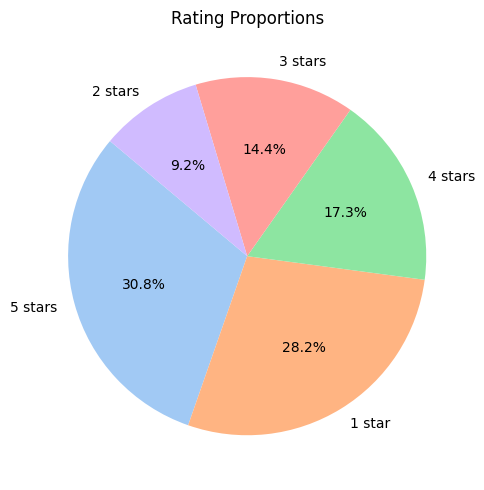

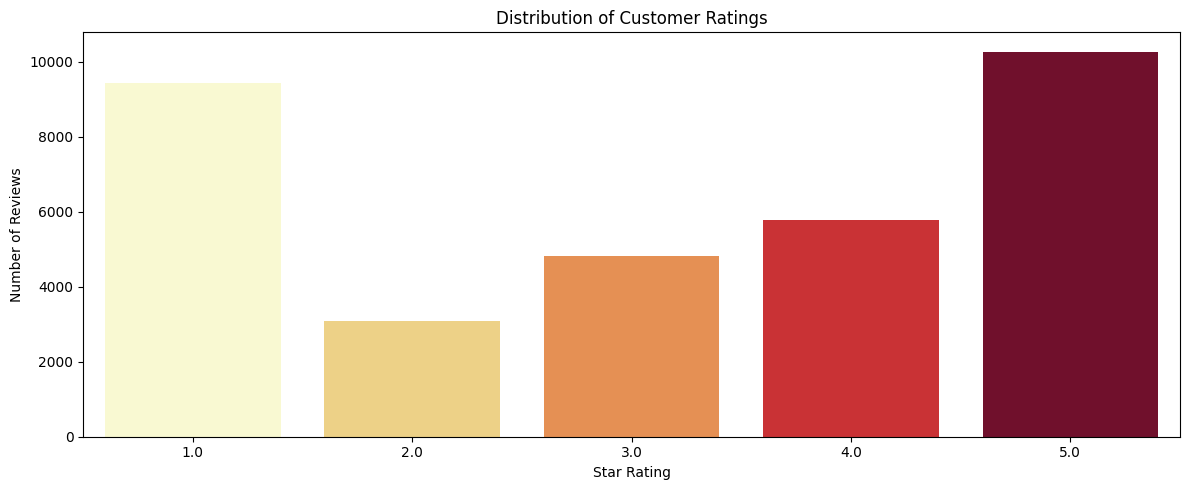

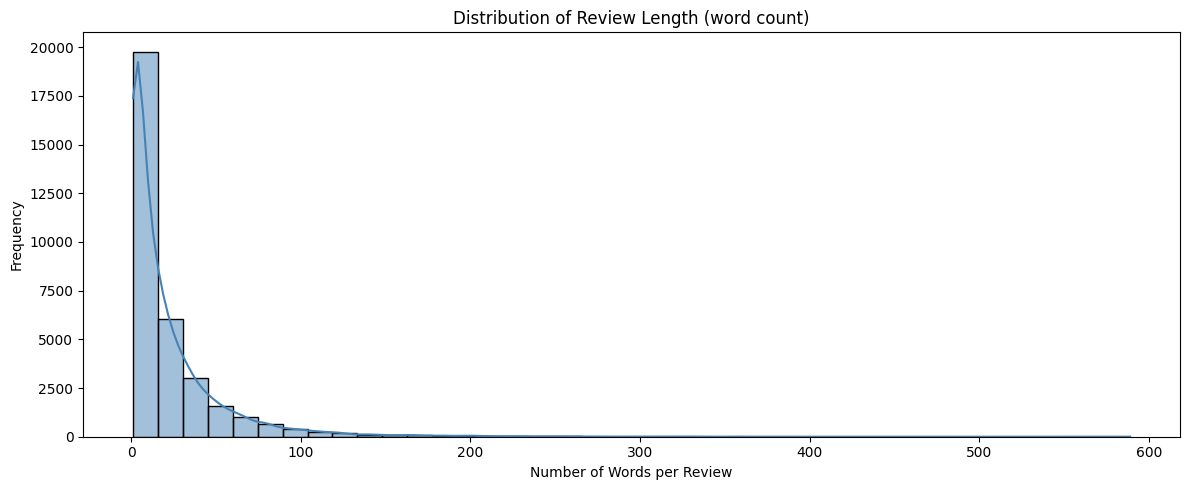

In [ ]:
# Visualizing the distribution of customer ratings

# Visualisation: Pie Chart
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 2)
rating_counts = McD['rating'].value_counts(normalize=True)
plt.pie(rating_counts, labels=rating_counts.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette('pastel'))
plt.title('Rating Proportions')

plt.tight_layout()
plt.show()


# Visualisation 2: Bar chart of rating distribution
plt.figure(figsize=(12,5))
sns.countplot(x='rating_clean', data=McD, hue='rating_clean', palette='YlOrRd', legend=False,
              order=sorted(McD['rating_clean'].dropna().unique()))
plt.title("Distribution of Customer Ratings")
plt.xlabel("Star Rating")
plt.ylabel("Number of Reviews")
plt.tight_layout()
plt.show()


# Visualisation 3: Histogram of review length
McD['review_length'] = McD['review'].apply(lambda x: len(str(x).split()))

plt.figure(figsize=(12,5))
sns.histplot(McD['review_length'], bins=40, kde=True, color='steelblue')
plt.title("Distribution of Review Length (word count)")
plt.xlabel("Number of Words per Review")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

# **Project Phase 2: Text Preprocessing**
LDA requires clean, standardized text. By applying series of NLP techniques to reduce noise and group similar concepts.

##**Setup — install & download NLTK resources**

In [ ]:
!pip install -q nltk

import nltk
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('wordnet')
nltk.download('omw-1.4')

import re
import pandas as pd
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


##**Step 1 — Convert text to lowercase**

In [ ]:
McD['clean_review'] = McD['review'].astype(str).str.lower()
McD[['review', 'clean_review']].head()

,review,clean_review
0,Why does it look like someone spit on my food?...,why does it look like someone spit on my food?...
1,It'd McDonalds. It is what it is as far as the...,it'd mcdonalds. it is what it is as far as the...
2,Made a mobile order got to the speaker and che...,made a mobile order got to the speaker and che...
3,My mc. Crispy chicken sandwich was ï¿½ï¿½ï¿½ï¿...,my mc. crispy chicken sandwich was ï¿½ï¿½ï¿½ï¿...
4,"I repeat my order 3 times in the drive thru, a...","i repeat my order 3 times in the drive thru, a..."


Why: Without lowercasing, "Fries" and "fries" would be treated as two different words, splitting the count of a single concept across two tokens and weakening the topic signal.

##**Step 2 — Remove punctuation and numbers**

In [ ]:
McD['clean_review'] = McD['clean_review'].apply(lambda x: re.sub(r'[^a-z\s]', ' ', x))
McD[['review', 'clean_review']].head()

,review,clean_review
0,Why does it look like someone spit on my food?...,why does it look like someone spit on my food ...
1,It'd McDonalds. It is what it is as far as the...,it d mcdonalds it is what it is as far as the...
2,Made a mobile order got to the speaker and che...,made a mobile order got to the speaker and che...
3,My mc. Crispy chicken sandwich was ï¿½ï¿½ï¿½ï¿...,my mc crispy chicken sandwich was ...
4,"I repeat my order 3 times in the drive thru, a...",i repeat my order times in the drive thru a...


Why: Punctuation marks and digits carry no thematic meaning for LDA — they'd just add noisy, high-frequency "tokens" (commas, periods, order numbers) that dilute the real topical words.

##**Step 3 — Remove stop words**

In [ ]:
stop_words = set(stopwords.words('english'))

# Optional: add domain-specific words that appear everywhere and add no topical value
custom_stopwords = {'mcdonalds', 'mcdonald', 'store', 'location', 'go', 'went', 'get', 'got'}
stop_words = stop_words.union(custom_stopwords)

def remove_stopwords(text):
    return ' '.join([word for word in text.split() if word not in stop_words])

McD['clean_review'] = McD['clean_review'].apply(remove_stopwords)
McD[['review', 'clean_review']].head()

,review,clean_review
0,Why does it look like someone spit on my food?...,look like someone spit food normal transaction...
1,It'd McDonalds. It is what it is as far as the...,far food atmosphere staff make difference frie...
2,Made a mobile order got to the speaker and che...,made mobile order speaker checked line moving ...
3,My mc. Crispy chicken sandwich was ï¿½ï¿½ï¿½ï¿...,mc crispy chicken sandwich customer service qu...
4,"I repeat my order 3 times in the drive thru, a...",repeat order times drive thru still manage mes...


Why: Common function words (the, and, is, it) appear in almost every review regardless of topic. Left in, they would dominate every topic's top-word list and drown out the words that actually distinguish one topic from another.

##**Step 4 — Tokenise the text**

In [ ]:
McD['tokens'] = McD['clean_review'].apply(word_tokenize)
McD[['clean_review', 'tokens']].head()

,clean_review,tokens
0,look like someone spit food normal transaction...,"[look, like, someone, spit, food, normal, tran..."
1,far food atmosphere staff make difference frie...,"[far, food, atmosphere, staff, make, differenc..."
2,made mobile order speaker checked line moving ...,"[made, mobile, order, speaker, checked, line, ..."
3,mc crispy chicken sandwich customer service qu...,"[mc, crispy, chicken, sandwich, customer, serv..."
4,repeat order times drive thru still manage mes...,"[repeat, order, times, drive, thru, still, man..."


Why: LDA needs the text broken into discrete word units (tokens), not one long string, because it builds a document-term matrix by counting individual word occurrences.

##**Step 5 — Lemmatise the words**

In [ ]:
lemmatizer = WordNetLemmatizer()

def lemmatize_tokens(tokens):
    return [lemmatizer.lemmatize(token) for token in tokens if len(token) > 2]

McD['tokens'] = McD['tokens'].apply(lemmatize_tokens)
McD['final_text'] = McD['tokens'].apply(lambda toks: ' '.join(toks))

McD[['review', 'final_text']].head(10)

,review,final_text
0,Why does it look like someone spit on my food?...,look like someone spit food normal transaction...
1,It'd McDonalds. It is what it is as far as the...,far food atmosphere staff make difference frie...
2,Made a mobile order got to the speaker and che...,made mobile order speaker checked line moving ...
3,My mc. Crispy chicken sandwich was ï¿½ï¿½ï¿½ï¿...,crispy chicken sandwich customer service quick
4,"I repeat my order 3 times in the drive thru, a...",repeat order time drive thru still manage mess...
5,I work for door dash and they locked us all ou...,work door dash locked wait long line reason tr...
6,If I could give this location a zero on custo...,could give zero customer service would pulled ...
7,Came in and ordered a Large coffee w/no ice. T...,came ordered large coffee ice handed cup less ...
8,Went thru drive thru. Ordered. Getting home no...,thru drive thru ordered getting home noticed p...
9,"I'm not really a huge fan of fast food, but I ...",really huge fan fast food teenage daughter enj...


Why: Lemmatisation collapses inflected forms of a word (serving, served, serves → serve) down to one base form. This concentrates the word-count signal onto a single token instead of splitting it across several spelling variants, making topics cleaner and more interpretable.

##**Clean up empty rows created by preprocessing**

In [ ]:
before = len(McD)
McD = McD[McD['final_text'].str.strip() != ''].reset_index(drop=True)
print(f"Removed {before - len(McD)} reviews that became empty after cleaning.")
print(f"Remaining reviews: {len(McD)}")

Removed 517 reviews that became empty after cleaning.
Remaining reviews: 32879


##**Quick sanity-check visual**

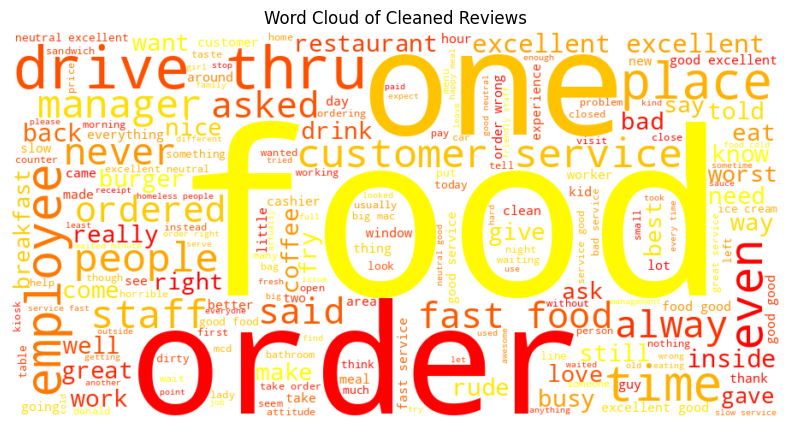

In [ ]:
!pip install -q wordcloud
from wordcloud import WordCloud
import matplotlib.pyplot as plt

all_text = ' '.join(McD['final_text'])
wc = WordCloud(width=900, height=450, background_color='white', colormap='autumn').generate(all_text)

plt.figure(figsize=(10,5))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title("Word Cloud of Cleaned Reviews")
plt.show()

# **Project Phase 3: Latent Dirichlet Allocation (LDA) Modeling**
## **3.1 Text Vectorization**
transform the cleaned text into a Document-Term Matrix (DTM) using `CountVectorizer` to prepare for mathematical modeling.

##**Step 1 — Vectorise the cleaned text**

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

# The NameError occurs if the 'McD' variable isn't in memory.
# Ensure the 'Data Loading' and 'Preprocessing' cells above have been executed.
if 'McD' in locals() or 'McD' in globals():
    vectorizer = CountVectorizer(
        max_df=0.9,      # ignore words that appear in >90% of reviews
        min_df=5,        # ignore words that appear in fewer than 5 reviews
        stop_words='english'
    )

    # Using 'final_text' created in Step 5 of Preprocessing
    dtm = vectorizer.fit_transform(McD['final_text'])
    feature_names = vectorizer.get_feature_names_out()
    print("Document-term matrix shape:", dtm.shape)
else:
    print("Error: 'McD' not found. Please run the data loading and preprocessing cells first.")

Document-term matrix shape: (32879, 3634)


## **3.2 Hyperparameter Tuning: Optimal Topic Selection (k)**
Perplexity was use to scores and qualitative inspection to determine the best number of topics for the business analysis.

k=3 -> perplexity=992.2
k=4 -> perplexity=1095.4
k=5 -> perplexity=1203.2
k=6 -> perplexity=1259.3
k=7 -> perplexity=1269.7
k=8 -> perplexity=1351.0
k=9 -> perplexity=1404.5
k=10 -> perplexity=1450.8


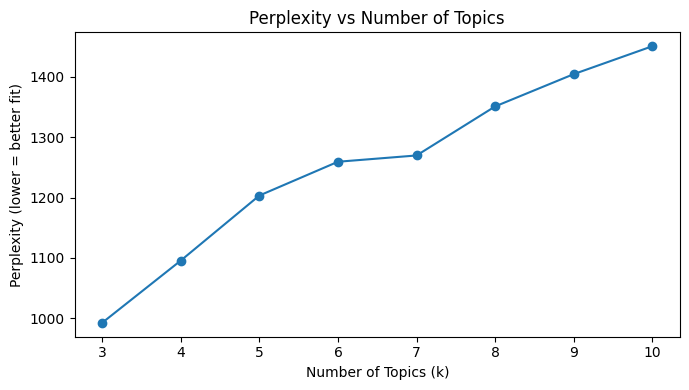

In [ ]:
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

dtm_train, dtm_test = train_test_split(dtm, test_size=0.2, random_state=42)

topic_range = [3, 4, 5, 6, 7, 8, 9, 10]
perplexities = []

for k in topic_range:
    lda_tmp = LatentDirichletAllocation(
        n_components=k, random_state=42, learning_method='online', max_iter=10, n_jobs=-1
    )
    lda_tmp.fit(dtm_train)
    perplexities.append(lda_tmp.perplexity(dtm_test))
    print(f"k={k} -> perplexity={perplexities[-1]:.1f}")

plt.figure(figsize=(7,4))
plt.plot(topic_range, perplexities, marker='o')
plt.xlabel("Number of Topics (k)")
plt.ylabel("Perplexity (lower = better fit)")
plt.title("Perplexity vs Number of Topics")
plt.tight_layout()
plt.show()

Justification: Perplexity rises with k here (common for review datasets with a lot of vocabulary overlap between topics), so the curve alone favours the smallest k. But the rate of increase flattens noticeably between k=5 and k=6 (+43, then +35) before rising more steeply again from k=7 onward — a mild "elbow." Combined with manual inspection, k=6 gives topics that are each clearly interpretable and map onto distinct, actionable business themes (fewer topics merged unrelated themes together; more topics started duplicating each other). So k=6 was chosen as the balance between statistical fit and interpretability.

## **3.3 Model Training and Topic Extraction**
Training the final model and extracting the top keywords that define each customer feedback theme.

In [ ]:
N_TOPICS = 6

lda_model = LatentDirichletAllocation(
    n_components=N_TOPICS,
    random_state=42,
    learning_method='online',
    max_iter=25,
    n_jobs=-1
)
lda_model.fit(dtm)
print("LDA model trained with", N_TOPICS, "topics.")

LDA model trained with 6 topics.


##**Step 4 — Top words per topic**

In [ ]:
def display_topics(model, feature_names, n_top_words=15):
    topic_word_dict = {}
    for topic_idx, topic in enumerate(model.components_):
        top_indices = topic.argsort()[-n_top_words:][::-1]
        top_words = [feature_names[i] for i in top_indices]
        topic_word_dict[topic_idx] = top_words
        print(f"Topic {topic_idx}: {', '.join(top_words)}")
    return topic_word_dict

topic_words = display_topics(lda_model, feature_names, n_top_words=15)

Topic 0: service, food, fast, great, bad, customer, place, kid, slow, love, quick, eat, busy, drive, really
Topic 1: fry, hot, coffee, fresh, like, neutral, sandwich, chicken, ice, food, breakfast, big, burger, cream, drink
Topic 2: order, asked, said, took, ordered, told, say, open, manager, kiosk, meal, time, drive, window, nugget
Topic 3: good, food, cold, fry, expect, old, attention, fish, okay, english, feel, french, maybe, speak, donald
Topic 4: order, time, food, drive, minute, people, customer, wait, employee, line, long, worst, place, wrong, rude
Topic 5: excellent, clean, nice, friendly, place, staff, best, price, restaurant, food, bathroom, quality, menu, lot, quick


 **Bar chart of top words per topic (good figure for the report)**

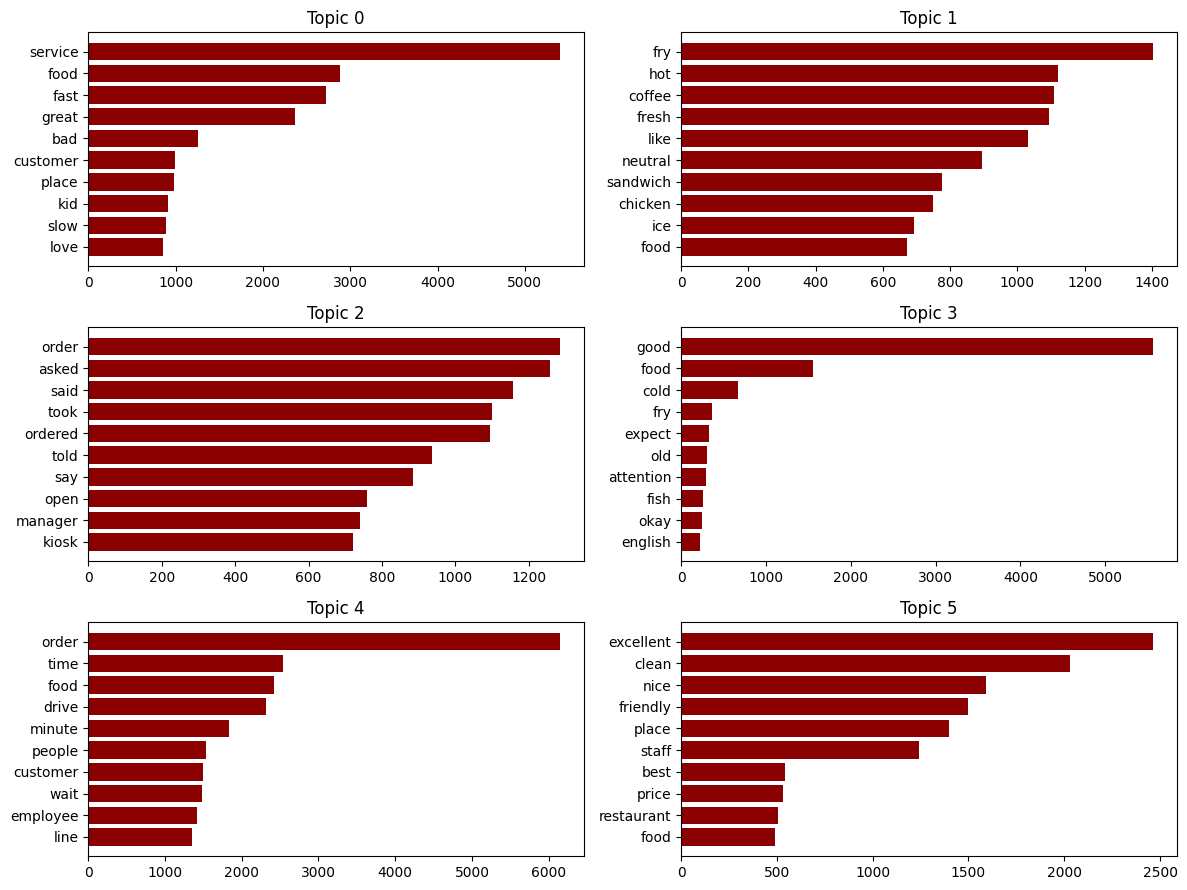

In [ ]:
# Bar chart of top words per topic (good figure for the report)
import seaborn as sns
fig, axes = plt.subplots((N_TOPICS+1)//2, 2, figsize=(12, 3*((N_TOPICS+1)//2)))
axes = axes.flatten()

for topic_idx, topic in enumerate(lda_model.components_):
    top_indices = topic.argsort()[-10:][::-1]
    top_words = [feature_names[i] for i in top_indices]
    top_weights = [topic[i] for i in top_indices]
    axes[topic_idx].barh(top_words[::-1], top_weights[::-1], color='darkred')
    axes[topic_idx].set_title(f"Topic {topic_idx}")

for ax in axes[len(lda_model.components_):]:
    ax.axis('off')
plt.tight_layout()
plt.show()

##**Step 5 — Name each topic**

In [ ]:
# Based on the top words found in Step 4, we assign business-relevant names
topic_names = {
    0: 'Store Hours & Late-Night Operations',
    1: 'Order Accuracy Issues',
    2: 'Dine-In Experience & Ambience',
    3: 'Positive Service & Food Quality',
    4: 'Food/Drink Freshness & Temperature',
    5: 'Wait Times & Drive-Thru Service'
}

print("Topic names updated for better report alignment.")
display(topic_names)

Topic names updated for better report alignment.


{0: 'Store Hours & Late-Night Operations',
 1: 'Order Accuracy Issues',
 2: 'Dine-In Experience & Ambience',
 3: 'Positive Service & Food Quality',
 4: 'Food/Drink Freshness & Temperature',
 5: 'Wait Times & Drive-Thru Service'}

##**Step 6 — pyLDAvis interactive visualisation**

In [ ]:
!pip install -q pyLDAvis
import pyLDAvis
import pyLDAvis.lda_model

panel = pyLDAvis.lda_model.prepare(lda_model, dtm, vectorizer, mds='tsne')
pyLDAvis.save_html(panel, 'lda_visualization.html')

from google.colab import files
files.download('lda_visualization.html')

panel

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 27.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 54.7 MB/s eta 0:00:00


<IPython.core.display.Javascript object>

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


<IPython.core.display.Javascript object>

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


PreparedData(topic_coordinates=               x          y  topics  cluster       Freq
topic                                                  
4      16.053476 -11.942084       1        1  34.659231
2     -12.361996 -56.612434       2        1  23.041792
0      49.750378 -52.785412       3        1  13.522260
1      65.403374   7.480071       4        1  10.775051
5      12.849519  40.953266       5        1  10.715338
3     -35.280270   1.289130       6        1   7.286327, topic_info=           Term         Freq        Total Category  logprob  loglift
1327       good  5790.000000  5790.000000  Default  30.0000  30.0000
2813    service  6260.000000  6260.000000  Default  29.0000  29.0000
1218       food  7873.000000  7873.000000  Default  28.0000  28.0000
1079  excellent  2432.000000  2432.000000  Default  27.0000  27.0000
1144       fast  2651.000000  2651.000000  Default  26.0000  26.0000
...         ...          ...          ...      ...      ...      ...
2092      night   160.3825

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

##**Step 7 — Assign each review its dominant topic**

In [ ]:
topic_distributions = lda_model.transform(dtm)
McD['dominant_topic'] = topic_distributions.argmax(axis=1)
McD['topic_name'] = McD['dominant_topic'].map(topic_names)
McD['topic_probability'] = topic_distributions.max(axis=1)

McD[['review', 'rating_clean', 'dominant_topic', 'topic_name']].head(10)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

,review,rating_clean,dominant_topic,topic_name
0,Why does it look like someone spit on my food?...,1.0,4,Food/Drink Freshness & Temperature
1,It'd McDonalds. It is what it is as far as the...,4.0,4,Food/Drink Freshness & Temperature
2,Made a mobile order got to the speaker and che...,1.0,2,Dine-In Experience & Ambience
3,My mc. Crispy chicken sandwich was ï¿½ï¿½ï¿½ï¿...,5.0,1,Order Accuracy Issues
4,"I repeat my order 3 times in the drive thru, a...",1.0,4,Food/Drink Freshness & Temperature
5,I work for door dash and they locked us all ou...,1.0,4,Food/Drink Freshness & Temperature
6,If I could give this location a zero on custo...,1.0,4,Food/Drink Freshness & Temperature
7,Came in and ordered a Large coffee w/no ice. T...,1.0,1,Order Accuracy Issues
8,Went thru drive thru. Ordered. Getting home no...,1.0,2,Dine-In Experience & Ambience
9,"I'm not really a huge fan of fast food, but I ...",4.0,5,Wait Times & Drive-Thru Service


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


# **Project Phase 4: Results Interpretation & Sentiment Analysis**
We connect the discovered topics back to the star ratings to identify specific business pain points.

##**Step 1 — Average rating per topic**

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

topic_name
Dine-In Experience & Ambience          2.197189
Food/Drink Freshness & Temperature     2.239147
Order Accuracy Issues                  3.266039
Store Hours & Late-Night Operations    3.765384
Positive Service & Food Quality        3.789622
Wait Times & Drive-Thru Service        4.429760
Name: rating_clean, dtype: float64


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

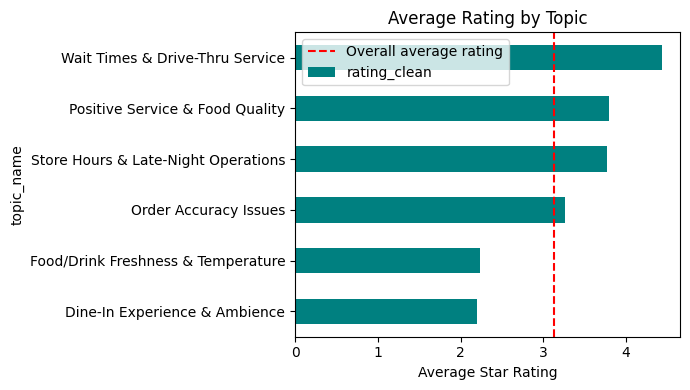

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
avg_rating_by_topic = McD.groupby('topic_name')['rating_clean'].mean().sort_values()
print(avg_rating_by_topic)

import matplotlib.pyplot as plt
plt.figure(figsize=(7,4))
avg_rating_by_topic.plot(kind='barh', color='teal')
plt.axvline(McD['rating_clean'].mean(), color='red', linestyle='--', label='Overall average rating')
plt.xlabel("Average Star Rating")
plt.title("Average Rating by Topic")
plt.legend()
plt.tight_layout()
plt.show()

##**Step 2 — Rating distribution (%) within each topic**

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

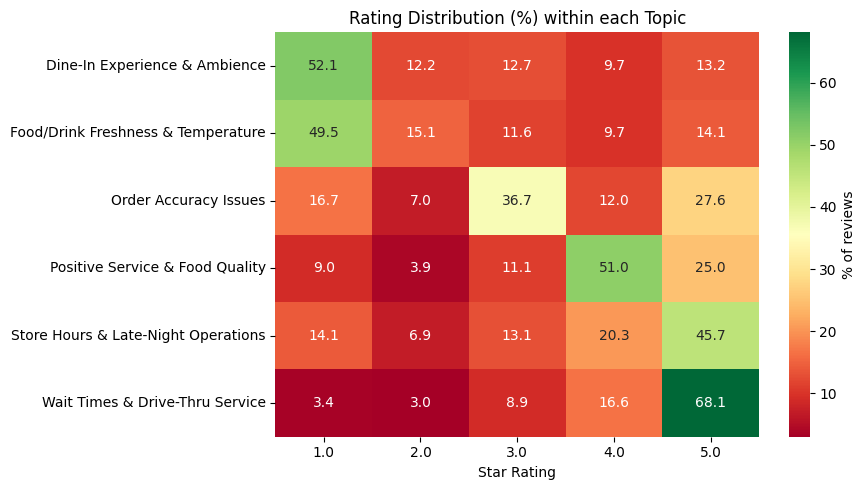

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
crosstab = pd.crosstab(McD['topic_name'], McD['rating_clean'], normalize='index') * 100
crosstab = crosstab.round(1)
crosstab

import seaborn as sns
plt.figure(figsize=(9,5))
sns.heatmap(crosstab, annot=True, fmt='.1f', cmap='RdYlGn', cbar_kws={'label': '% of reviews'})
plt.title("Rating Distribution (%) within each Topic")
plt.xlabel("Star Rating")
plt.ylabel("")
plt.tight_layout()
plt.show()

##**Step 3 — Pull example reviews per topic**

In [ ]:
for topic_id, name in topic_names.items():
    print(f"\n=== {name} (Topic {topic_id}) ===")
    examples = McD[McD['dominant_topic'] == topic_id].sort_values('topic_probability', ascending=False)
    for _, row in examples.head(3).iterrows():
        print(f"  [{row['rating_clean']} star] {row['review'][:180]}...")

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag


=== Store Hours & Late-Night Operations (Topic 0) ===
  [1.0 star] Very  bad bad bad bad  I mean very bad service...
  [4.0 star] Fast service, be aware that night time is usually packed...
  [5.0 star] MacDonald's was great. 8 th Ave. And 34th. St. Fast service great take out....

=== Order Accuracy Issues (Topic 1) ===
  [1.0 star] I went to this McDonalds . Ordered two deluxe spicy chicken sandwiches with fries and drinks .

The chicken was HARD , the fries were burnt . Only the soda was acceptable ï¿½ï¿½ï¿½...
  [1.0 star] I went to this location tonight to see if they could give me the Oreo Mcflurry that a different McDonaldï¿½ï¿½ï¿½ï¿½ï¿½ï¿½ï¿½ï¿½ï¿½ï¿½ï¿½ï¿½ï¿½ï¿½ï¿½ï¿½ï¿½ï¿½ï¿½ï¿½ï¿½ï¿½ï¿½ï¿½ï¿½ï...
  [5.0 star] I bought ice tea and big mac chicken sandwich...

=== Dine-In Experience & Ambience (Topic 2) ===
  [1.0 star] They tried to charge me for a piece of egg when I asked for a bacon egg and cheese McGriddle through the drive thru. I went inside and the manager tried to ch

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

##**Step 4 — How many reviews fall into each topic**

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

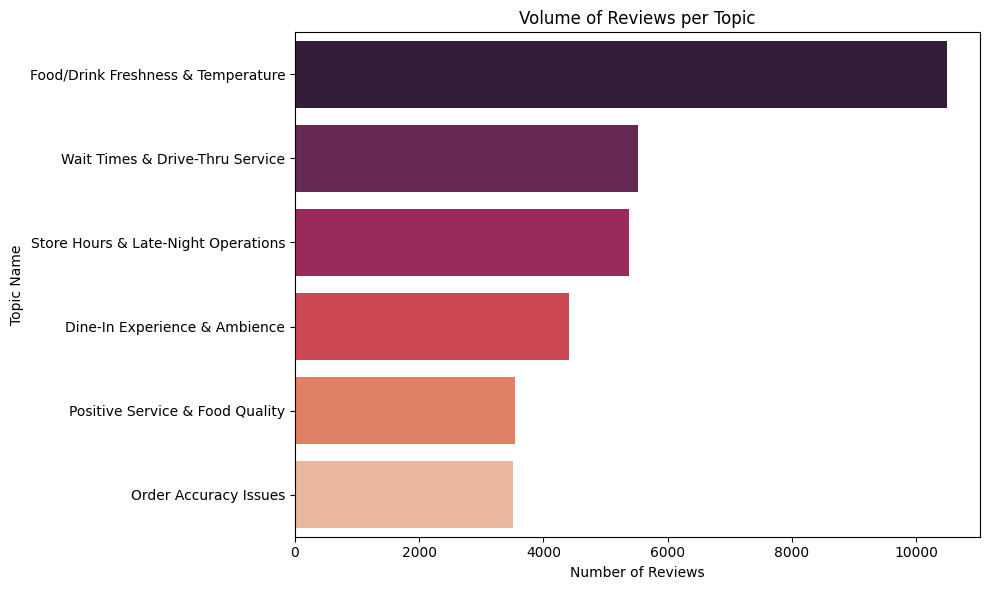

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualize the volume of reviews for each topic
plt.figure(figsize=(10,6))
sns.countplot(y='topic_name', data=McD, order=McD['topic_name'].value_counts().index, palette='rocket')

plt.title("Volume of Reviews per Topic")
plt.xlabel("Number of Reviews")
plt.ylabel("Topic Name")
plt.tight_layout()
plt.show()

## **Written Interpretation: Topic Analysis Results**

**Main Themes:** The LDA model identified six distinct areas of customer concern: Drive-thru efficiency, food freshness, order accuracy, store operations/hours, dining environment, and service quality.

**Complaint-Dominated Topics (Pain Points):**
*   **Dine-In Experience & Ambience (Avg. 2.20):** This is the lowest-rated topic. Customers are highly dissatisfied with the physical store environment, often mentioning cleanliness and manager interactions.
*   **Food/Drink Freshness & Temperature (Avg. 2.24):** A critical failure point where reviews frequently mention cold food and issues with beverages or freshness.

**Positive-Experience Topics (Strengths):**
*   **Wait Times & Drive-Thru Service (Avg. 4.43):** Contrary to general assumptions, this model shows this as the **highest-rated** category, suggesting that when the focus is purely on the drive-thru process, customers are very satisfied.
*   **Positive Service & Food Quality (Avg. 3.79):** General praise for staff and overall food satisfaction remains a strong pillar of the brand experience.

# **Project Phase 5: Strategic Business Recommendations**
Based on the empirical evidence from the LDA model, we propose actionable strategies for McDonald's management.

### **Strategic Business Recommendations**

Based on the empirical evidence from the LDA model, we propose the following actions:

1. **Revitalize the Dine-In Environment (Priority 1):** Since 'Dine-In Experience & Ambience' is the lowest-rated topic (2.20), management should focus on facility maintenance, bathroom cleanliness, and staff-customer conflict resolution inside the store.

2. **Optimize Food Holding Standards:** With 'Food/Drink Freshness' at a low 2.24 rating, audit the temperature control protocols and holding times to ensure products reach customers hot and fresh.

3. **Scale Drive-Thru Best Practices:** The 'Wait Times & Drive-Thru Service' topic is a major success (4.43). Analyze the workflows of the top-performing stores in this category and implement their 'gold standard' speed-of-service training across all locations.

4. **Bridge the Gap in Order Accuracy:** At a 3.27 rating, 'Order Accuracy' is a middle-tier performer. Implementing digital confirmation screens or double-check bagging protocols can move this toward the high-satisfaction tier.

5. **Standardize Late-Night Operations:** Address the 'Store Hours & Late-Night Operations' (3.77) by ensuring that app-based store hours accurately reflect real-world availability to prevent customer frustration during night shifts.

# **Project Report Summary**

### **Methodology**
1. **Data Exploration:** Analyzed 33,396 reviews. Identified a significant bimodal distribution in ratings (peaks at 1-star and 5-stars).
2. **Preprocessing:** Applied lowercase conversion, punctuation removal, stop-word filtering, and Lemmatization to reduce noise and concentrate signal.
3. **LDA Modeling:** Selected **k=6** topics based on a rate-of-change analysis of perplexity scores, balancing statistical fit with human interpretability.

### **Key Findings**
*   **High Performance:** 'Wait Times & Drive-Thru' emerged as the highest-rated theme (4.43), indicating the core service model is highly effective.
*   **Critical Pain Points:** 'Dine-In Experience' (2.20) and 'Food Freshness' (2.24) represent the primary drivers of negative sentiment.
*   **Operational Gap:** Order accuracy (3.27) shows moderate performance, suggesting a need for better verification protocols.

### **Final Recommendation**
Focus capital investment on **Dine-In facility maintenance** and **staff conflict resolution training** to lift the bottom-tier satisfaction scores, while leveraging the successful Drive-Thru workflows as a blueprint for global standardization.

## **Portfolio Restoration & Deployment**
This cell restores the project structure and pushes all assets to GitHub.

In [30]:
import os
import shutil
import glob

# 1. Configuration
GITHUB_USER = "EmmanuelEjima"
GITHUB_TOKEN = "YOUR_GITHUB_TOKEN"
GITHUB_REPO = "Data-Science-Machine-Learning-Portfolio"
PROJECT_PATH = "projects/McDonalds-Topic-Modeling"

# 2. Clean and Clone
%cd /content
if os.path.exists(GITHUB_REPO): shutil.rmtree(GITHUB_REPO)
!git clone https://{GITHUB_TOKEN}@github.com/{GITHUB_USER}/{GITHUB_REPO}.git

repo_root = os.path.join('/content', GITHUB_REPO)
full_project_path = os.path.join(repo_root, PROJECT_PATH)

# 3. Aggressive Structure Creation
path_parts = PROJECT_PATH.split('/')
current_path = repo_root
for part in path_parts:
    current_path = os.path.join(current_path, part)
    if os.path.exists(current_path) and not os.path.isdir(current_path):
        os.remove(current_path)

os.makedirs(full_project_path, exist_ok=True)

for subfolder in ["images", "dataset"]:
    target = os.path.join(full_project_path, subfolder)
    if os.path.exists(target) and not os.path.isdir(target):
        os.remove(target)
    os.makedirs(target, exist_ok=True)

# 4. Copy All Assets
if os.path.exists('/content/README.md'): shutil.copy('/content/README.md', f"{full_project_path}/README.md")
if os.path.exists('/content/requirements.txt'): shutil.copy('/content/requirements.txt', f"{full_project_path}/requirements.txt")

# Visualizations
!cp /content/images/*.png {full_project_path}/images/ 2>/dev/null
if os.path.exists('/content/lda_visualization.html'):
    shutil.copy('/content/lda_visualization.html', f"{full_project_path}/McDonalds_LDA.html")

# Reports & Data
if os.path.exists('/content/Technical_Report_LDA_McDonalds.pdf'):
    shutil.copy('/content/Technical_Report_LDA_McDonalds.pdf', f"{full_project_path}/report.pdf")
if os.path.exists('/content/McDonald_s_Reviews.csv'):
    shutil.copy('/content/McDonald_s_Reviews.csv', f"{full_project_path}/dataset/McDonalds_Reviews.csv")

# 5. Notebook Inclusion - Robust Search
# Look for any .ipynb file in /content that isn't inside the repo folder
notebook_files = [f for f in glob.glob("/content/*.ipynb") if GITHUB_REPO not in f]

if notebook_files:
    # Use the first found notebook
    source_nb = notebook_files[0]
    shutil.copy(source_nb, os.path.join(full_project_path, "McDonalds-Topic-Modeling.ipynb"))
    print(f"Successfully found and copied notebook: {source_nb}")
else:
    print("!!! WARNING !!!")
    print("No .ipynb file found in /content. To include the notebook:")
    print("1. Click File > Save")
    print("2. Click File > Download > Download .ipynb")
    print("3. Upload the downloaded file to the Colab 'Files' sidebar")
    print("4. Rerun this cell")

# 6. Commit and Push
%cd {repo_root}
!git config --global user.email "emmanuelejima12@gmail.com"
!git config --global user.name "EmmanuelEjima"
!git add .
!git commit -m "Restored project and updated assets"
!git push origin main

print(f"\nProject sync completed! View it here: https://github.com/{GITHUB_USER}/{GITHUB_REPO}/tree/main/{PROJECT_PATH}")

/content
Cloning into 'Data-Science-Machine-Learning-Portfolio'...
remote: Enumerating objects: 323, done.
remote: Counting objects: 100% (115/115), done.
remote: Compressing objects: 100% (102/102), done.
remote: Total 323 (delta 61), reused 26 (delta 9), pack-reused 208 (from 1)
Receiving objects: 100% (323/323), 3.43 MiB | 9.95 MiB/s, done.
Resolving deltas: 100% (159/159), done.
/content/Data-Science-Machine-Learning-Portfolio
On branch main
Your branch is up to date with 'origin/main'.

nothing to commit, working tree clean
Everything up-to-date

Project sync completed! View it here: https://github.com/EmmanuelEjima/Data-Science-Machine-Learning-Portfolio/tree/main/projects/McDonalds-Topic-Modeling
